In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("EDA") \
    .master("local[*]") \
    .getOrCreate()

In [ ]:
df = spark.read.csv(
    "hdfs://master:9000/DACK/weatherAUS.csv",
    header=True,
    inferSchema=True,
    nullValue="NA"
)

Structure Analysis

In [ ]:
df.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Location: string (nullable = true)
 |-- MinTemp: double (nullable = true)
 |-- MaxTemp: double (nullable = true)
 |-- Rainfall: double (nullable = true)
 |-- Evaporation: double (nullable = true)
 |-- Sunshine: double (nullable = true)
 |-- WindGustDir: string (nullable = true)
 |-- WindGustSpeed: integer (nullable = true)
 |-- WindDir9am: string (nullable = true)
 |-- WindDir3pm: string (nullable = true)
 |-- WindSpeed9am: integer (nullable = true)
 |-- WindSpeed3pm: integer (nullable = true)
 |-- Humidity9am: integer (nullable = true)
 |-- Humidity3pm: integer (nullable = true)
 |-- Pressure9am: double (nullable = true)
 |-- Pressure3pm: double (nullable = true)
 |-- Cloud9am: integer (nullable = true)
 |-- Cloud3pm: integer (nullable = true)
 |-- Temp9am: double (nullable = true)
 |-- Temp3pm: double (nullable = true)
 |-- RainToday: string (nullable = true)
 |-- RainTomorrow: string (nullable = true)



In [ ]:
print("The number of rows:", df.count())
print("The number of collumns:", len(df.columns))

The number of rows: 145460
The number of collumns: 23


In [ ]:
total_rows = df.count()
distinct_rows = df.distinct().count()

print("Duplicate rows:", total_rows - distinct_rows)

Duplicate rows: 0


In [ ]:
df.show(10)

+----------+--------+-------+-------+--------+-----------+--------+-----------+-------------+----------+----------+------------+------------+-----------+-----------+-----------+-----------+--------+--------+-------+-------+---------+------------+
|      Date|Location|MinTemp|MaxTemp|Rainfall|Evaporation|Sunshine|WindGustDir|WindGustSpeed|WindDir9am|WindDir3pm|WindSpeed9am|WindSpeed3pm|Humidity9am|Humidity3pm|Pressure9am|Pressure3pm|Cloud9am|Cloud3pm|Temp9am|Temp3pm|RainToday|RainTomorrow|
+----------+--------+-------+-------+--------+-----------+--------+-----------+-------------+----------+----------+------------+------------+-----------+-----------+-----------+-----------+--------+--------+-------+-------+---------+------------+
|2008-12-01|  Albury|   13.4|   22.9|     0.6|       NULL|    NULL|          W|           44|         W|       WNW|          20|          24|         71|         22|     1007.7|     1007.1|       8|    NULL|   16.9|   21.8|       No|          No|
|2008-12-02|

Missing Value Analysis

In [ ]:
from pyspark.sql.functions import col, when, count

missing_df = df.select([
    count(
        when(
            col(c).isNull(),
            c
        )
    ).alias(c)
    for c in df.columns
])

missing_df.show()

+----+--------+-------+-------+--------+-----------+--------+-----------+-------------+----------+----------+------------+------------+-----------+-----------+-----------+-----------+--------+--------+-------+-------+---------+------------+
|Date|Location|MinTemp|MaxTemp|Rainfall|Evaporation|Sunshine|WindGustDir|WindGustSpeed|WindDir9am|WindDir3pm|WindSpeed9am|WindSpeed3pm|Humidity9am|Humidity3pm|Pressure9am|Pressure3pm|Cloud9am|Cloud3pm|Temp9am|Temp3pm|RainToday|RainTomorrow|
+----+--------+-------+-------+--------+-----------+--------+-----------+-------------+----------+----------+------------+------------+-----------+-----------+-----------+-----------+--------+--------+-------+-------+---------+------------+
|   0|       0|   1485|   1261|    3261|      62790|   69835|      10326|        10263|     10566|      4228|        1767|        3062|       2654|       4507|      15065|      15028|   55888|   59358|   1767|   3609|     3261|        3267|
+----+--------+-------+-------+-----

In [ ]:
from pyspark.sql.functions import *

missing_pct_df = df.select([
    round(
        count(
            when(col(c).isNull(), c)
        ) / count("*") * 100,
        2
    ).alias(c)
    for c in df.columns
])

missing_pct_df.show()

+----+--------+-------+-------+--------+-----------+--------+-----------+-------------+----------+----------+------------+------------+-----------+-----------+-----------+-----------+--------+--------+-------+-------+---------+------------+
|Date|Location|MinTemp|MaxTemp|Rainfall|Evaporation|Sunshine|WindGustDir|WindGustSpeed|WindDir9am|WindDir3pm|WindSpeed9am|WindSpeed3pm|Humidity9am|Humidity3pm|Pressure9am|Pressure3pm|Cloud9am|Cloud3pm|Temp9am|Temp3pm|RainToday|RainTomorrow|
+----+--------+-------+-------+--------+-----------+--------+-----------+-------------+----------+----------+------------+------------+-----------+-----------+-----------+-----------+--------+--------+-------+-------+---------+------------+
| 0.0|     0.0|   1.02|   0.87|    2.24|      43.17|   48.01|        7.1|         7.06|      7.26|      2.91|        1.21|        2.11|       1.82|        3.1|      10.36|      10.33|   38.42|   40.81|   1.21|   2.48|     2.24|        2.25|
+----+--------+-------+-------+-----

In [ ]:
from pyspark.sql.functions import *
import pandas as pd

missing_pct = df.select([
    round(
        count(when(col(c).isNull(), c)) / count("*") * 100,
        2
    ).alias(c)
    for c in df.columns
]).first().asDict()

missing_vl_df = pd.DataFrame([
    [
        c,
        p,
        (
            "No Missing" if p == 0 else
            "Low Missing" if p < 5 else
            "Moderate Missing" if p < 30 else
            "High Missing" if p < 50 else
            "Critical Missing"
        )
    ]
    for c, p in sorted(
        missing_pct.items(),
        key=lambda x: x[1],
        reverse=True
    )
],
columns=[
    "Column",
    "MissingPercent",
    "Severity"
])

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

missing_vl_df

,Column,MissingPercent,Severity
0,Sunshine,48.01,High Missing
1,Evaporation,43.17,High Missing
2,Cloud3pm,40.81,High Missing
3,Cloud9am,38.42,High Missing
4,Pressure9am,10.36,Moderate Missing
5,Pressure3pm,10.33,Moderate Missing
6,WindDir9am,7.26,Moderate Missing
7,WindGustDir,7.10,Moderate Missing
8,WindGustSpeed,7.06,Moderate Missing
9,Humidity3pm,3.10,Low Missing


Descriptive Statistics

In [ ]:
df.describe().show()

+-------+--------+------------------+------------------+------------------+------------------+------------------+-----------+-----------------+----------+----------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+-----------------+---------+------------+
|summary|Location|           MinTemp|           MaxTemp|          Rainfall|       Evaporation|          Sunshine|WindGustDir|    WindGustSpeed|WindDir9am|WindDir3pm|      WindSpeed9am|      WindSpeed3pm|       Humidity9am|       Humidity3pm|       Pressure9am|       Pressure3pm|          Cloud9am|         Cloud3pm|           Temp9am|          Temp3pm|RainToday|RainTomorrow|
+-------+--------+------------------+------------------+------------------+------------------+------------------+-----------+-----------------+----------+----------+------------------+------------------+------------------+------------------+-----

Numeric Analysis

In [ ]:
from pyspark.sql.types import *

numeric_cols = [

    field.name

    for field in df.schema.fields

    if isinstance(
        field.dataType,
        (
            IntegerType,
            DoubleType
        )
    )
]

print(numeric_cols)

['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']


In [ ]:
for c in numeric_cols:

    median = df.approxQuantile(
        c,
        [0.5],
        0
    )[0]

    print(f"{c} median:", median)

MinTemp median: 12.0
MaxTemp median: 22.6
Rainfall median: 0.0
Evaporation median: 4.8
Sunshine median: 8.4
WindGustSpeed median: 39.0
WindSpeed9am median: 13.0
WindSpeed3pm median: 19.0
Humidity9am median: 70.0
Humidity3pm median: 52.0
Pressure9am median: 1017.6
Pressure3pm median: 1015.2
Cloud9am median: 5.0
Cloud3pm median: 5.0
Temp9am median: 16.7
Temp3pm median: 21.1


Categorical Analysis


In [ ]:
from pyspark.sql import functions as F


categorical_cols = [
    "Location",
    "WindGustDir",
    "WindDir9am",
    "WindDir3pm",
    "RainToday",
    "RainTomorrow"
]

for c in categorical_cols:

    print(f"\n{c}")

    print(
        "Distinct values:",
        df.select(c).distinct().count()
    )

    df.groupBy(c) \
      .count() \
      .orderBy(F.desc("count")) \
      .show(30)


Location
Distinct values: 49
+-------------+-----+
|     Location|count|
+-------------+-----+
|     Canberra| 3436|
|       Sydney| 3344|
|     Brisbane| 3193|
|    Melbourne| 3193|
|     Adelaide| 3193|
|        Perth| 3193|
|       Hobart| 3193|
|       Darwin| 3193|
|       Cairns| 3040|
|      Bendigo| 3040|
|   Wollongong| 3040|
|     Ballarat| 3040|
|    GoldCoast| 3040|
|       Albury| 3040|
|  MountGinini| 3040|
|   Townsville| 3040|
|       Albany| 3040|
| MountGambier| 3040|
| AliceSprings| 3040|
|   Launceston| 3040|
|  Tuggeranong| 3039|
|      Penrith| 3039|
|    Newcastle| 3039|
|NorfolkIsland| 3009|
|        Cobar| 3009|
|SydneyAirport| 3009|
|  Williamtown| 3009|
|        Moree| 3009|
|      Mildura| 3009|
|     Portland| 3009|
+-------------+-----+
only showing top 30 rows

WindGustDir
Distinct values: 17
+-----------+-----+
|WindGustDir|count|
+-----------+-----+
|       NULL|10326|
|          W| 9915|
|         SE| 9418|
|          N| 9313|
|        SSE| 9216|
|   

Target Analysis

+------------+------+
|RainTomorrow| count|
+------------+------+
|        NULL|  3267|
|          No|110316|
|         Yes| 31877|
+------------+------+



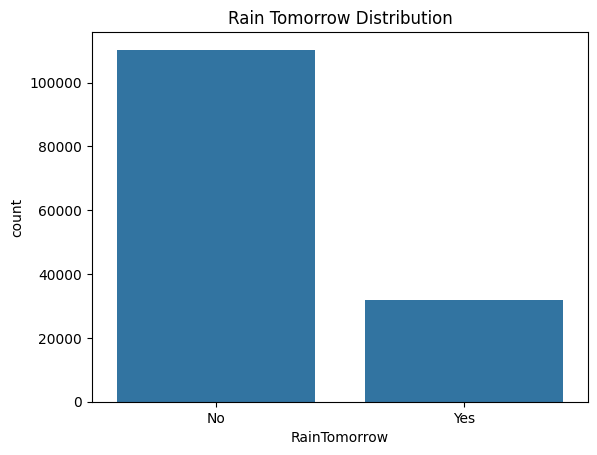

In [ ]:
df.groupBy("RainTomorrow") \
  .count() \
  .show()

pdf = df.toPandas()

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x="RainTomorrow",
    data=pdf
)

plt.title("Rain Tomorrow Distribution")
plt.show()

Outlier Analysis

In [ ]:
#convert datatype
from pyspark.sql.functions import col
numeric_cols = [
    "MinTemp", "MaxTemp", "Rainfall",
    "Evaporation", "Sunshine",
    "WindGustSpeed",
    "WindSpeed9am", "WindSpeed3pm",
    "Humidity9am", "Humidity3pm",
    "Pressure9am", "Pressure3pm",
    "Cloud9am", "Cloud3pm",
    "Temp9am", "Temp3pm"
]

for c in numeric_cols:
   df = df.withColumn(c, col(c).try_cast("double"))

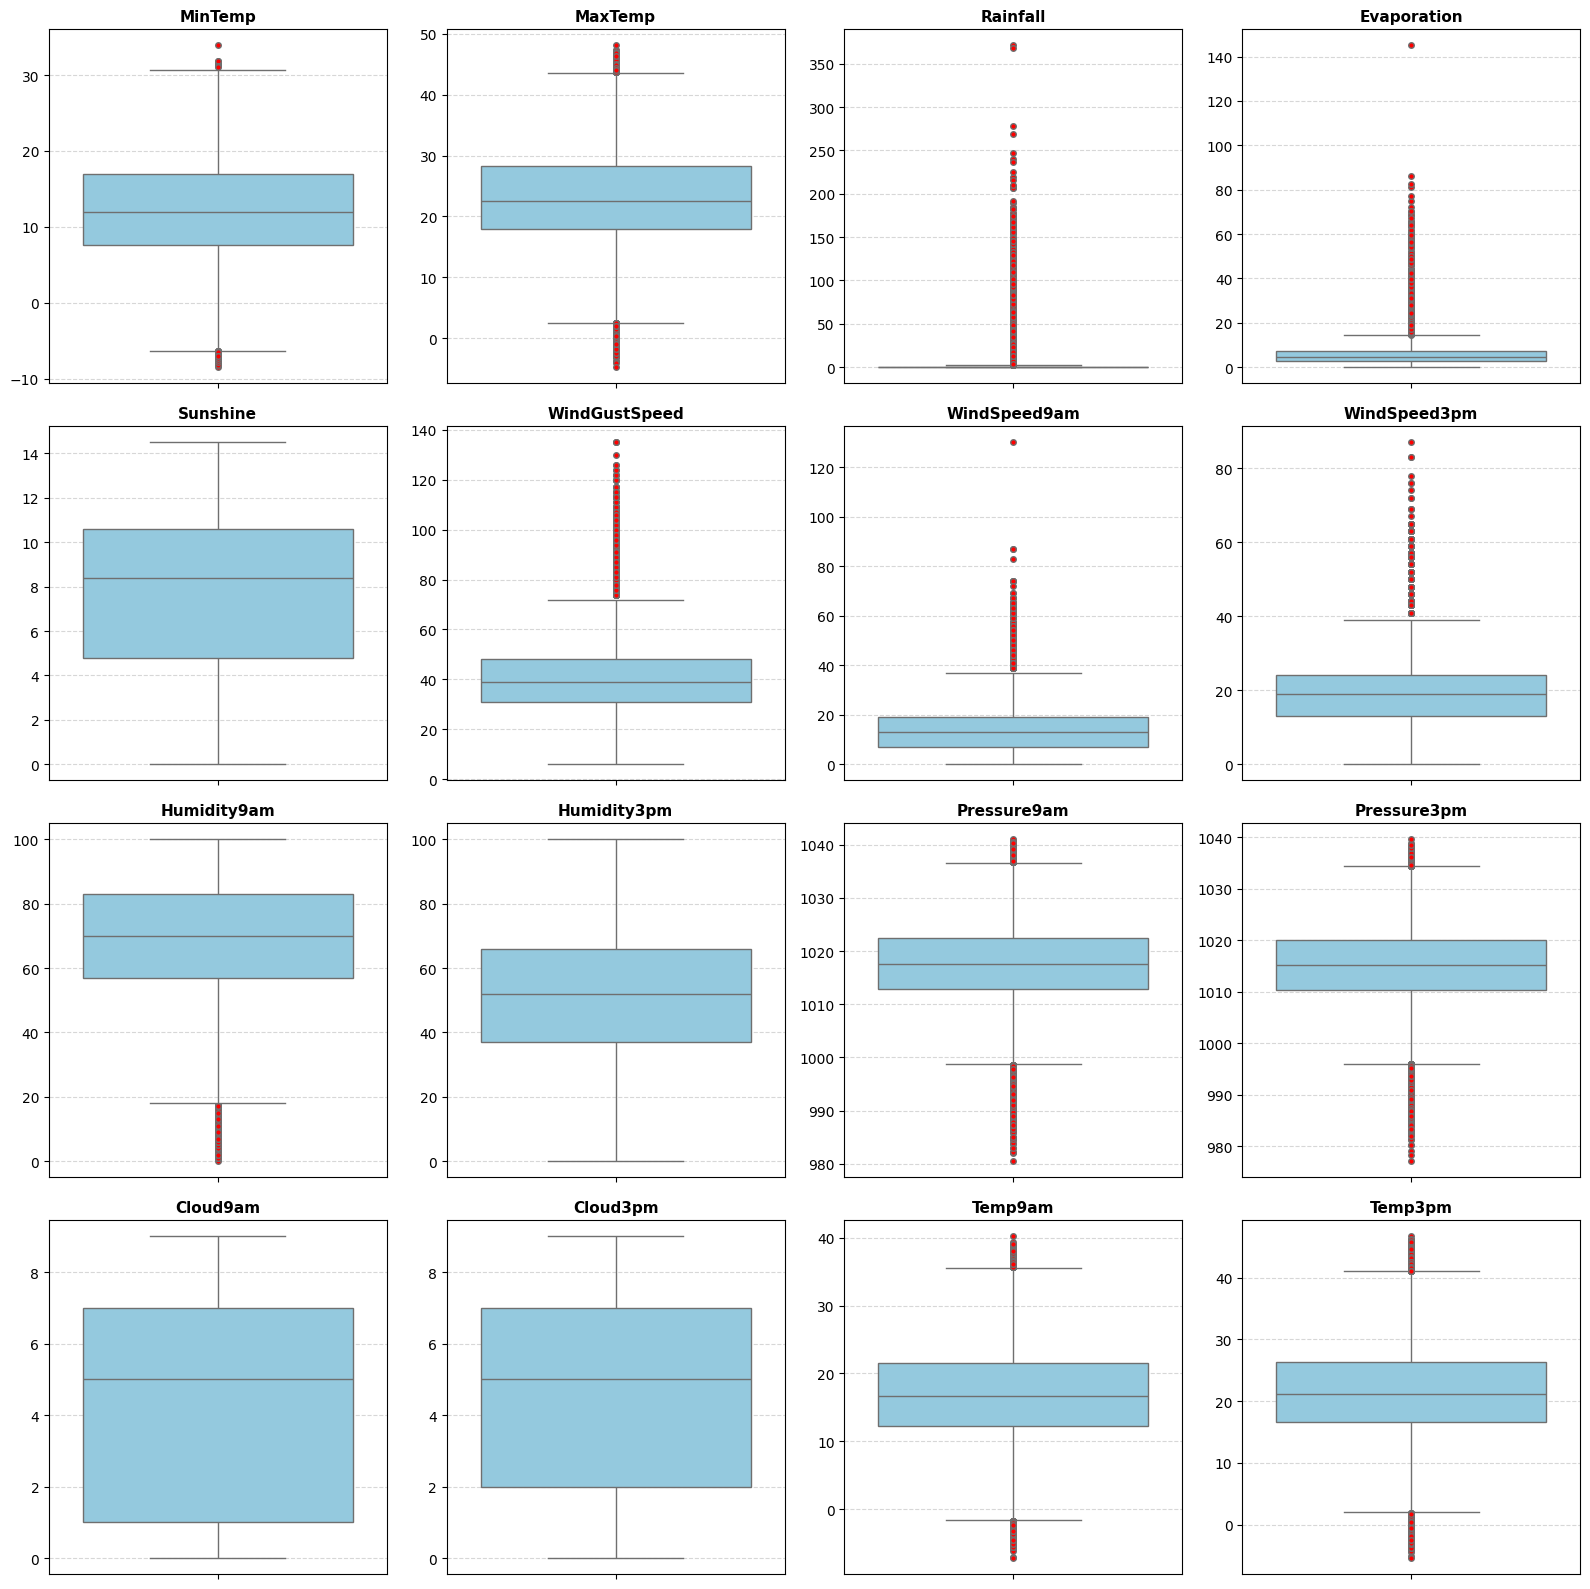

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

pdf_numeric = df.select(numeric_cols).toPandas()

# Thiết lập kích thước lưới (4 cột, số hàng tự động tính dựa trên số lượng biến)
num_cols = 4
num_rows = math.ceil(len(numeric_cols) / num_cols)

# Tạo khung vẽ tổng (Figure)
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))
axes = axes.flatten()

# Vòng lặp vẽ từng Boxplot vào từng ô lưới
for i, col_name in enumerate(numeric_cols):
    sns.boxplot(
        y=pdf_numeric[col_name],
        ax=axes[i],
        color='skyblue',
        flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 4}
    )

    axes[i].set_title(f'{col_name}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Xóa bỏ các ô đồ thị trống (nếu số lượng biến không lấp đầy lưới)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Tự động căn chỉnh để các đồ thị không đè lên nhau
plt.tight_layout()
plt.show()

Correlation Analysis

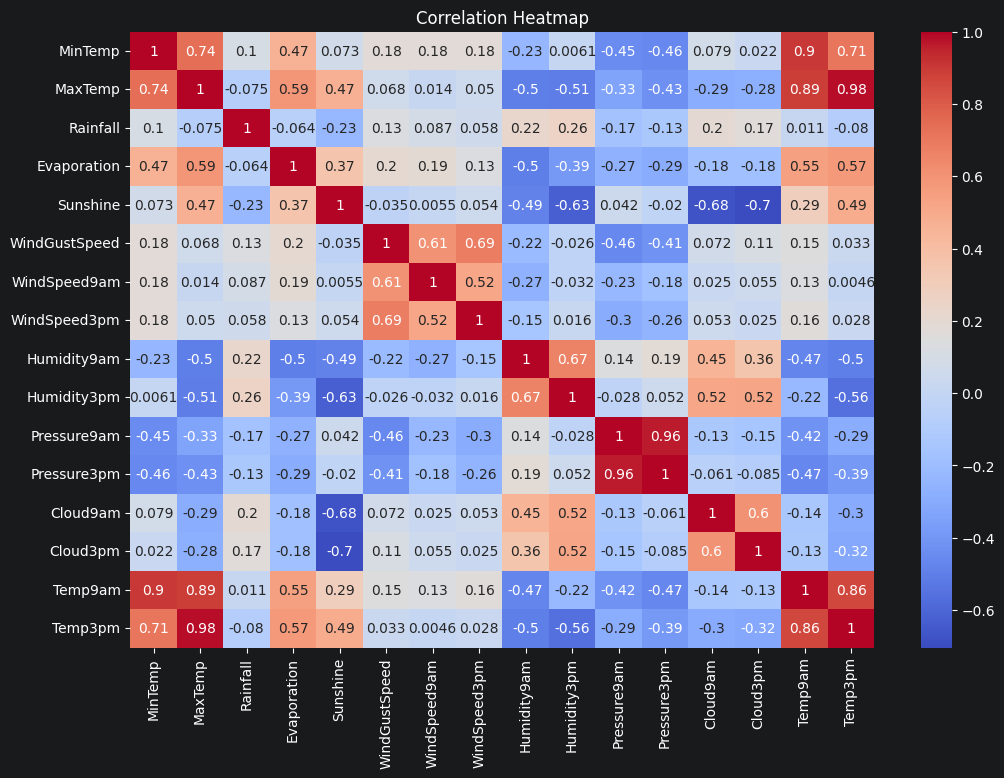

In [ ]:
numeric_df = pdf.select_dtypes(
    include=['float64', 'int64']
)
corr_matrix = numeric_df.corr()
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

Time & Geographic Analysis

In [ ]:
import pyspark.sql.functions as F

#Kiểm tra bộ dữ liệu có bao nhiêu năm
total_years = df.select("Year").distinct().count()
print(f"Total years in dataset: {total_years}\n")

Total years in dataset: 11



In [ ]:
monthly_rain = df.groupBy("Month") \
    .agg(
        avg("Rainfall").alias("avg_rainfall")
    ) \
    .orderBy("Month")

monthly_pdf = monthly_rain.toPandas()

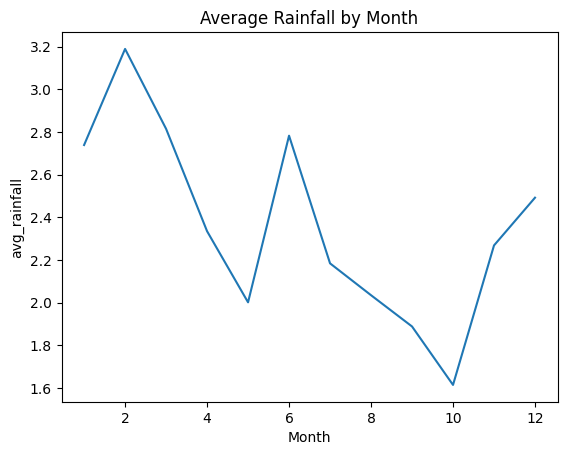

In [ ]:
sns.lineplot(
    x="Month",
    y="avg_rainfall",
    data=monthly_pdf
)

plt.title("Average Rainfall by Month")
plt.show()

In [ ]:
from pyspark.sql.functions import avg

df.groupBy("Location") \
  .agg(
      avg("Rainfall").alias("avg_rainfall")
  ) \
  .orderBy(
      col("avg_rainfall").desc()
  ) \
  .show()

+-------------+------------------+
|     Location|      avg_rainfall|
+-------------+------------------+
|       Cairns| 5.742034805890243|
|       Darwin| 5.092452239273417|
| CoffsHarbour| 5.061496782932628|
|    GoldCoast|3.7693959731543734|
|   Wollongong|3.5949027498323303|
|  Williamtown|3.5911084998041507|
|   Townsville|  3.48559182327728|
|    NorahHead|3.3872994195971353|
|       Sydney| 3.324543002697027|
|  MountGinini|3.2922600619195004|
|    Katherine|3.2010897435897436|
|    Newcastle| 3.183891708967855|
|     Brisbane|3.1448908573236363|
|NorfolkIsland|3.1276653171389963|
|SydneyAirport| 3.009916805324462|
|      Walpole|2.9068463994324123|
|  Witchcliffe|2.8956639566395626|
|     Portland|  2.53037383177569|
|       Albany|2.2638594164456163|
|BadgerysCreek| 2.193101092896165|
+-------------+------------------+
only showing top 20 rows


In [ ]:
df.groupBy("Location") \
  .agg(
      avg("MaxTemp").alias("avg_max_temp")
  ) \
  .orderBy(
      col("avg_max_temp").desc()
  ) \
  .show(10)

+------------+------------------+
|    Location|      avg_max_temp|
+------------+------------------+
|   Katherine| 34.93543563068914|
|      Darwin| 32.54097744360893|
|       Uluru|30.383195416931855|
|      Cairns|29.558848684210492|
|  Townsville| 29.36716025008228|
|AliceSprings|29.248420013166562|
|       Moree|26.950548354935197|
|     Woomera| 26.59670658682631|
|    Brisbane|26.448379993708784|
|  PearceRAAF|26.051238286479286|
+------------+------------------+
only showing top 10 rows


In [ ]:
df_month = df.withColumn(
   "Month",
   F.month("DateParsed")
)

df_month.groupBy("Month") \
       .agg(
           F.avg("Rainfall").alias("AvgRainfall"),
           F.avg("MaxTemp").alias("AvgTemp")
       ) \
       .orderBy("Month") \
       .show()

+-----+------------------+------------------+
|Month|       AvgRainfall|           AvgTemp|
+-----+------------------+------------------+
|    1| 2.738477621186322|29.532383498854085|
|    2| 3.188665083135409| 28.87350900225055|
|    3| 2.814450069029017|26.885273428636282|
|    4|2.3348226134654713| 23.62503502626962|
|    5|2.0016541583703598|20.065173453997012|
|    6|2.7821820529374275|17.307647666746213|
|    7| 2.184209185839224|16.744580229346276|
|    8|2.0349825724730235| 18.24101255230131|
|    9|1.8885432272847535|20.752011767759775|
|   10|1.6147320294640666|23.537153156173996|
|   11|2.2681770560502987|26.181246766683923|
|   12|2.4918354137771717|27.558321194464614|
+-----+------------------+------------------+

